Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use a parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

## Path to PE result file

In [2]:
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_1_samples.hdf5" #"/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection_params_TEOB_chi0_9_ecc0_1_samples.dat"#"/Users/arif/Desktop/injection.dat"

## Post-process the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [3]:
from gw_eccentricity.posterior.post_process_for_bilby import PostProcessForBilby

/Users/arif/gw_eccentricity/gw_eccentricity/load_data.py:7: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [4]:
import sys
sys.path.append("/Users/arif/teobresums_reviewed/Python/")

In [5]:
from teob_backward_evolution import teob_data_dict_generator

Check that the data_dict generated using `dataDict_generator` makes sense

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# Posteriors

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [7]:
egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file)

11:50 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


# Looking at the original posteriors

In [8]:
egwBilby.get_posterior()

,H1_log_likelihood,H1_matched_filter_snr,H1_optimal_snr,L1_log_likelihood,L1_matched_filter_snr,L1_optimal_snr,L1_time,V1_log_likelihood,V1_matched_filter_snr,V1_optimal_snr,...,spin_2x,spin_2y,spin_2z,symmetric_mass_ratio,theta_jn,tilt_1,tilt_2,total_mass,total_mass_source,waveform_approximant
0,642.244607,35.918966+ 1.120761j,35.831208,786.576196,39.735859+ 2.685366j,40.685512,2.014532,93.723387,13.834536+ 0.735283j,13.035710,...,0,0,0.798733,0.249997,0.165312,0.0,0.0,114.925349,85.395160,TEOBResumSDALI
1,638.881643,35.845015+ 0.285656j,35.747027,790.612963,39.855802- 0.532349j,40.310218,2.020555,92.147539,13.771259+ 1.041622j,13.040246,...,0,0,0.869048,0.249812,0.868342,0.0,0.0,115.825070,92.219946,TEOBResumSDALI
2,641.240977,35.889588+ 1.055960j,36.549083,791.754094,39.865177+ 0.412687j,41.311934,2.018724,91.914656,13.698957- 0.953750j,13.142518,...,0,0,0.823274,0.249975,0.016295,0.0,0.0,115.859640,85.977965,TEOBResumSDALI
3,639.929236,35.861708- 0.984852j,34.991833,790.770762,39.848323- 1.348160j,39.575562,2.017619,93.839661,13.862214+ 1.161800j,12.773486,...,0,0,0.857436,0.249850,0.552771,0.0,0.0,115.415046,87.782773,TEOBResumSDALI
4,644.043908,35.971668- 1.058499j,35.962850,788.506990,39.786549+ 2.405355j,41.011720,2.022157,93.465209,13.820257+ 2.036690j,13.262796,...,0,0,0.872537,0.249926,0.363407,0.0,0.0,115.413808,86.685991,TEOBResumSDALI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16950,644.253668,35.974407- 0.486238j,36.510340,803.262780,40.153950- 0.031349j,41.360050,2.020671,95.365006,13.953582+ 0.154471j,13.235293,...,0,0,0.892571,0.249760,0.334688,0.0,0.0,119.134495,88.685123,TEOBResumSDALI
16951,644.349724,35.984644+ 0.859281j,35.882990,802.862689,40.150961- 0.202095j,40.485264,2.020614,95.127924,13.957269+ 0.339040j,12.930671,...,0,0,0.882906,0.249726,0.622837,0.0,0.0,118.601786,90.548882,TEOBResumSDALI
16952,645.240287,36.005601+ 0.128633j,35.465572,801.905229,40.123475- 0.081116j,40.113629,2.021055,95.490492,13.972244- 0.002361j,12.870162,...,0,0,0.867660,0.249969,0.464586,0.0,0.0,117.915818,88.498913,TEOBResumSDALI
16953,645.362410,36.009158+ 0.110706j,36.640333,802.054341,40.127372- 0.516507j,41.402617,2.021319,95.323522,13.960679- 0.321529j,13.281066,...,0,0,0.873803,0.249943,0.488178,0.0,0.0,118.518660,89.623920,TEOBResumSDALI


In [9]:
injection = egwBilby.get_injection()

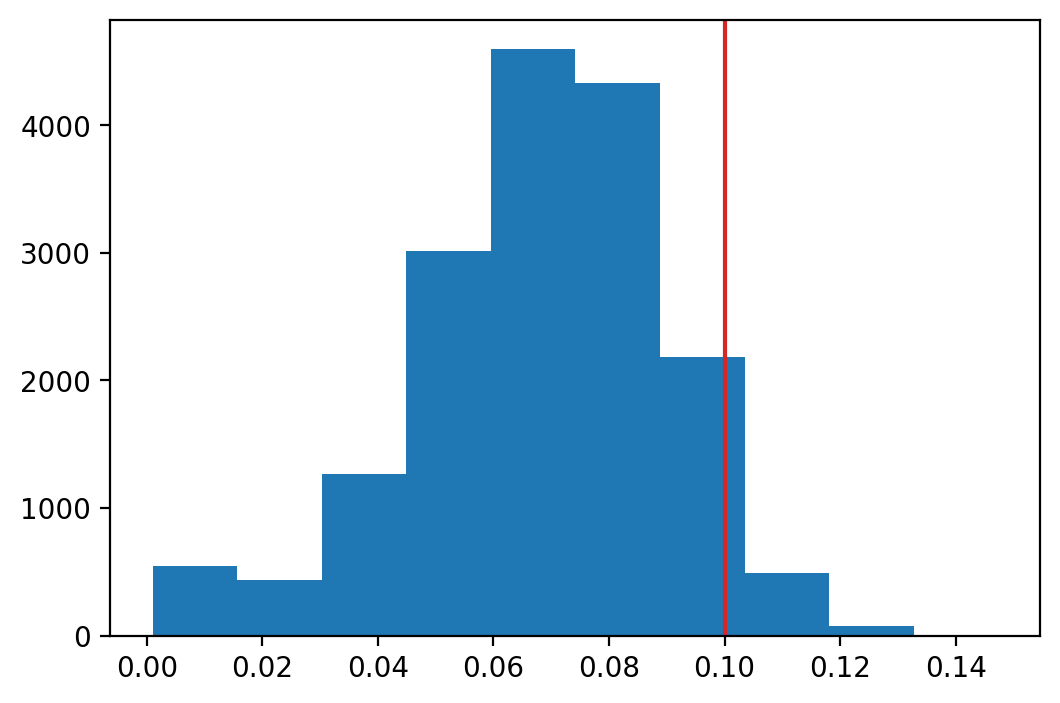

In [10]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 10})
ax.axvline(injection["eccentricity"], c="tab:red")

In [12]:
data_dict = egwBilby.get_injection_data_dict()

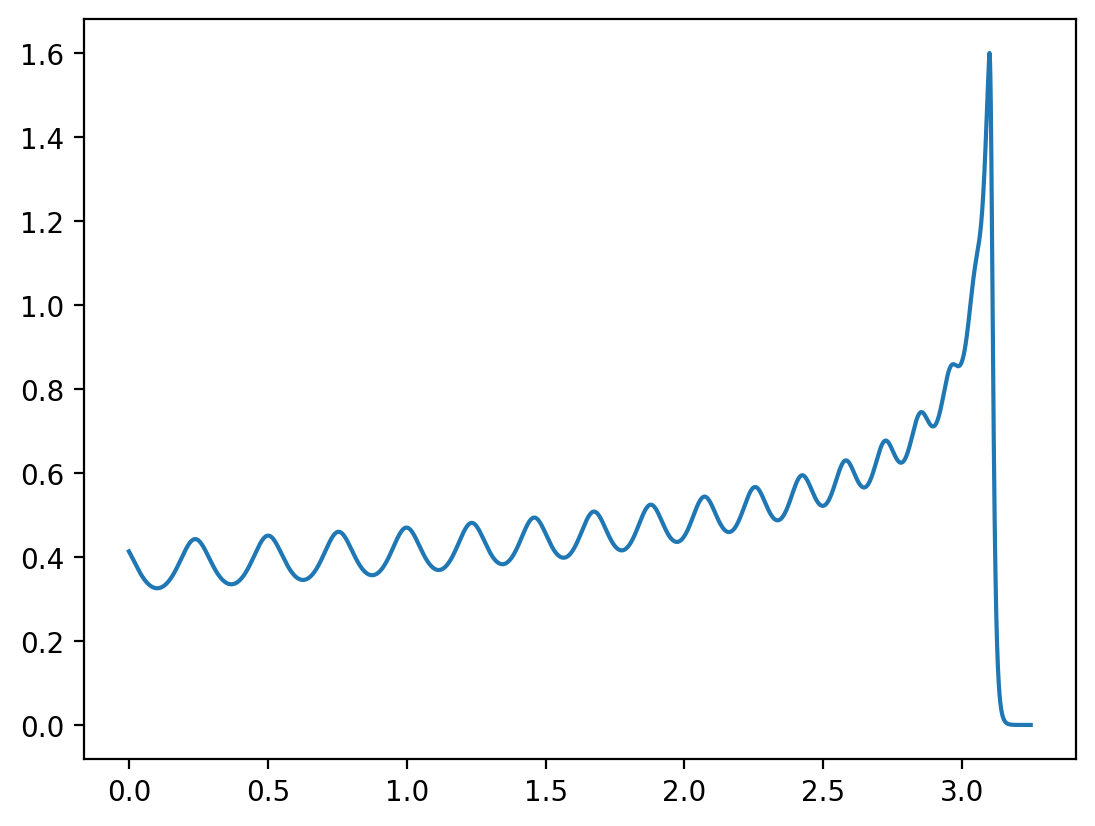

In [13]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

# Getting the best fref to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [14]:
from gw_eccentricity.posterior.post_process import get_fref_bounds_for_sample

In [48]:
# some settings to use
method = "Amplitude"
gw_eccentricity_kwargs = {"extra_kwargs": {
    # "omega_gw_extrema_interpolation_method": "spline"
}}
samples = np.arange(0, 1000)
n_jobs = 6

We can check the range of frequencies where eccentricity and mean anomaly could be measured using the following method

In [49]:
params = egwBilby.posterior.iloc[0].to_dict()

In [50]:
get_fref_bounds_for_sample(
    params=params, 
    data_dict_generator=egwBilby.data_dict_generator, 
    data_dict_generator_kwargs=egwBilby.data_dict_generator_kwargs,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs
)

{'method': 'Amplitude',
 'status': 'success',
 'fref_min': np.float64(8.939450736869187),
 'fref_max': np.float64(12.537667744103047),
 'params': {'H1_log_likelihood': 642.2446068486145,
  'H1_matched_filter_snr': np.complex128(35.918965951068294+1.120761462758923j),
  'H1_optimal_snr': 35.83120789832852,
  'L1_log_likelihood': 786.576196023626,
  'L1_matched_filter_snr': np.complex128(39.735859105488004+2.6853655025631995j),
  'L1_optimal_snr': 40.68551155772552,
  'L1_time': 2.0145321713493276,
  'V1_log_likelihood': 93.72338682491106,
  'V1_matched_filter_snr': np.complex128(13.834536216746264+0.7352825972576129j),
  'V1_optimal_snr': 13.035710344486567,
  'a_1': 0.8701674802663172,
  'a_2': 0.7987329541072407,
  'chi_1': 0.8701674802663172,
  'chi_1_in_plane': 0.0,
  'chi_2': 0.7987329541072407,
  'chi_2_in_plane': 0.0,
  'chi_eff': 0.8345808690560054,
  'chi_p': 0.0,
  'chirp_mass': 50.02376214277464,
  'chirp_mass_source': 37.17010403659305,
  'comoving_distance': 1402.7684359858

Get the range of frequencies where we can measure egw and lgw. We take only a few samples to see this to save time.

In [51]:
egwBilby.get_fref_bounds(samples=samples,
                         method=method,
                         n_jobs=n_jobs,
                         gw_eccentricity_kwargs=gw_eccentricity_kwargs
                        )

Getting fref bounds:   2%|███▍                                                                                                                                             | 24/1000 [00:00<00:10, 91.81it/s]/Users/arif/gw_eccentricity/gw_eccentricity/posterior/post_process.py:94: UserWarning: Sample {'H1_log_likelihood': 641.6015419629589, 'H1_matched_filter_snr': (35.899245662173264+0.9507756416480976j), 'H1_optimal_snr': 35.62063816367142, 'L1_log_likelihood': 795.8591230074798, 'L1_matched_filter_snr': (39.96788453032619+0.20973373949137858j), 'L1_optimal_snr': 40.24549995676002, 'L1_time': 2.021079676875235, 'V1_log_likelihood': 91.34134210288613, 'V1_matched_filter_snr': (13.655540038479558-2.084926162257154j), 'V1_optimal_snr': 12.783860023949641, 'a_1': 0.8642571245649159, 'a_2': 0.8899500902216075, 'chi_1': 0.8642571245649159, 'chi_1_in_plane': 0.0, 'chi_2': 0.8899500902216075, 'chi_2_in_plane': 0.0, 'chi_eff': 0.8759958270999357, 'chi_p': 0.0, 'chirp_mass': 51.31522769509849, 'c

{'fref_bounds': (np.float64(9.084302296173474), np.float64(9.026488048808366)),
 'success_percentage': 98.5,
 'failed_cases': [{'H1_log_likelihood': 641.6015419629589,
   'H1_matched_filter_snr': (35.899245662173264+0.9507756416480976j),
   'H1_optimal_snr': 35.62063816367142,
   'L1_log_likelihood': 795.8591230074798,
   'L1_matched_filter_snr': (39.96788453032619+0.20973373949137858j),
   'L1_optimal_snr': 40.24549995676002,
   'L1_time': 2.021079676875235,
   'V1_log_likelihood': 91.34134210288613,
   'V1_matched_filter_snr': (13.655540038479558-2.084926162257154j),
   'V1_optimal_snr': 12.783860023949641,
   'a_1': 0.8642571245649159,
   'a_2': 0.8899500902216075,
   'chi_1': 0.8642571245649159,
   'chi_1_in_plane': 0.0,
   'chi_2': 0.8899500902216075,
   'chi_2_in_plane': 0.0,
   'chi_eff': 0.8759958270999357,
   'chi_p': 0.0,
   'chirp_mass': 51.31522769509849,
   'chirp_mass_source': 37.79913902117098,
   'comoving_distance': 1445.9655499177725,
   'cos_tilt_1': 1.0,
   'cos_til

# Post-processing

We can measure eccentricity and mean anomaly for any sample using the following method

In [39]:
from gw_eccentricity.posterior.post_process import measure_eccentricity_for_sample

Post-process a given sample

In [40]:
fref = 10
measure_eccentricity_for_sample(
    params=params,
    data_dict_generator=egwBilby.data_dict_generator,
    data_dict_generator_kwargs=egwBilby.data_dict_generator_kwargs,
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

{'method': 'AmplitudeFits',
 'fref': 10,
 'status': 'success',
 'eccentricity': np.float64(0.007231260949142171),
 'mean_anomaly': np.float64(1.0146769826913804),
 'params': {'H1_log_likelihood': 642.2446068486145,
  'H1_matched_filter_snr': np.complex128(35.918965951068294+1.120761462758923j),
  'H1_optimal_snr': 35.83120789832852,
  'L1_log_likelihood': 786.576196023626,
  'L1_matched_filter_snr': np.complex128(39.735859105488004+2.6853655025631995j),
  'L1_optimal_snr': 40.68551155772552,
  'L1_time': 2.0145321713493276,
  'V1_log_likelihood': 93.72338682491106,
  'V1_matched_filter_snr': np.complex128(13.834536216746264+0.7352825972576129j),
  'V1_optimal_snr': 13.035710344486567,
  'a_1': 0.8701674802663172,
  'a_2': 0.7987329541072407,
  'chi_1': 0.8701674802663172,
  'chi_1_in_plane': 0.0,
  'chi_2': 0.7987329541072407,
  'chi_2_in_plane': 0.0,
  'chi_eff': 0.8345808690560054,
  'chi_p': 0.0,
  'chirp_mass': 50.02376214277464,
  'chirp_mass_source': 37.17010403659305,
  'comovin

We can postprocess a subset of the smaples or all the samples using the following method

In [41]:
import time

In [42]:
fref = 10
t_start = time.perf_counter()
egwBilby.post_process(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Post-processing samples:   0%|                                                                                                                                                      | 0/1000 [00:00<?, ?it/s]/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational

In [43]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 58.69757895800012 seconds for 1000 samples on 6 cores.


## View the results

In [44]:
egwBilby.post_process_result[:5]

[{'method': 'AmplitudeFits',
  'fref': 10,
  'status': 'success',
  'eccentricity': np.float64(0.007231260949142171),
  'mean_anomaly': np.float64(1.0146769826913804),
  'params': {'H1_log_likelihood': 642.2446068486145,
   'H1_matched_filter_snr': (35.918965951068294+1.120761462758923j),
   'H1_optimal_snr': 35.83120789832852,
   'L1_log_likelihood': 786.576196023626,
   'L1_matched_filter_snr': (39.735859105488004+2.6853655025631995j),
   'L1_optimal_snr': 40.68551155772552,
   'L1_time': 2.0145321713493276,
   'V1_log_likelihood': 93.72338682491106,
   'V1_matched_filter_snr': (13.834536216746264+0.7352825972576129j),
   'V1_optimal_snr': 13.035710344486567,
   'a_1': 0.8701674802663172,
   'a_2': 0.7987329541072407,
   'chi_1': 0.8701674802663172,
   'chi_1_in_plane': 0.0,
   'chi_2': 0.7987329541072407,
   'chi_2_in_plane': 0.0,
   'chi_eff': 0.8345808690560054,
   'chi_p': 0.0,
   'chirp_mass': 50.02376214277464,
   'chirp_mass_source': 37.17010403659305,
   'comoving_distance': 

In [45]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
    # debug=True
)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

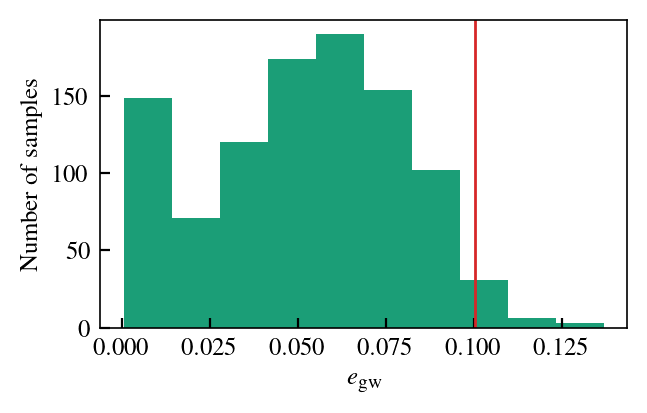

In [46]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")

(<Figure size 600x400 with 1 Axes>, <Axes: >)

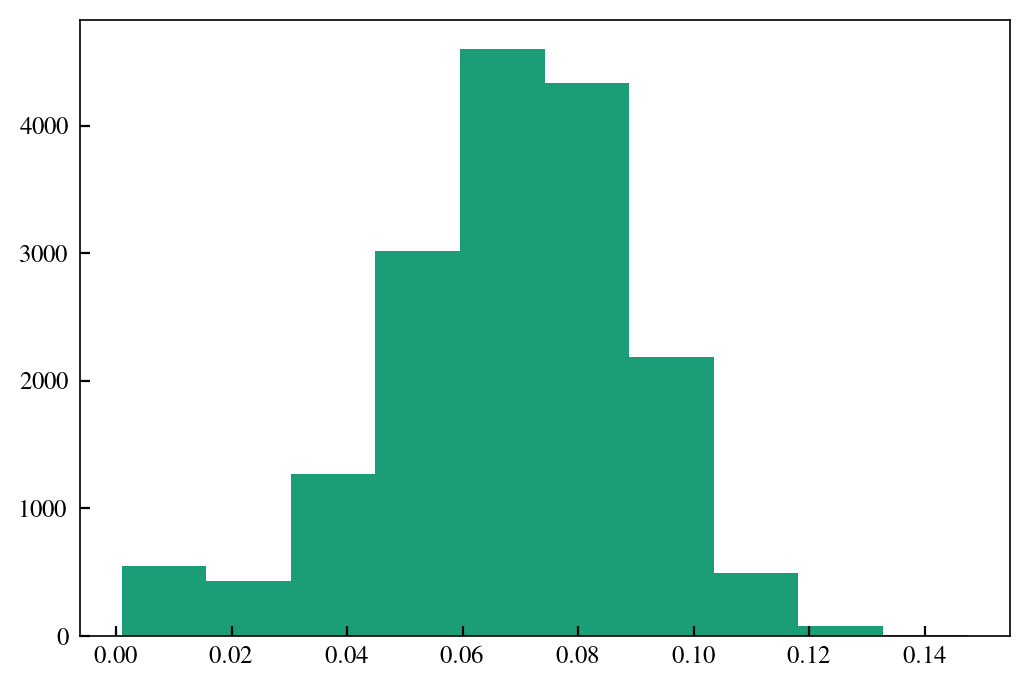

In [47]:
egwBilby.plot_eccentricity_posterior()

## Get a summary of the post-process, like how many cases were successfully post-processed

In [44]:
egwBilby.post_process_summary()

{'total_samples': 1000,
 'success_percentage': 100.0,
 'fref': 10,
 'method': 'AmplitudeFits',
 'eccentricity': [np.float64(0.35274067986995084),
  np.float64(0.3493114151362695),
  np.float64(0.35903151990418425),
  np.float64(0.3300606690705985),
  np.float64(0.35618468097422373),
  np.float64(0.35773681179057837),
  np.float64(0.35788833018137256),
  np.float64(0.3519526926697223),
  np.float64(0.35333804281347536),
  np.float64(0.35533718776966594),
  np.float64(0.3333132076683235),
  np.float64(0.33585428718991384),
  np.float64(0.35174674275015483),
  np.float64(0.3219714834642732),
  np.float64(0.34082714437131556),
  np.float64(0.35714225031344127),
  np.float64(0.35322762036740785),
  np.float64(0.34663703430044424),
  np.float64(0.3364287550870688),
  np.float64(0.33269433978426943),
  np.float64(0.3256689725270471),
  np.float64(0.31652311797757815),
  np.float64(0.3355569249662007),
  np.float64(0.33040579707691764),
  np.float64(0.34260343167542984),
  np.float64(0.3509156